HS4002 Group Project

Data Cleaning
I think we need to clean our data first...


In [24]:
# !pip install pandas numpy scipy plotnine

import pandas as pd
import numpy as np
import plotnine as p9
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import skew, kurtosis

In [25]:
raw_df = pd.read_csv("Census_data.csv")
raw_df

,"Resident Population by Planning Area/Subzone, Single Year of Age and Sex, June 2026",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NaN,NaN,NaN,NaN,NaN
1,Planning Area,Subzone,Age,Sex,2026
2,Total,Total,Total,Total,"4,231,520"
3,Total,Total,Total,Males,"2,055,410"
4,Total,Total,Total,Females,"2,176,120"
...,...,...,...,...,...
107091,Note:,NaN,NaN,NaN,NaN
107092,Planning areas refer to areas demarcated in th...,NaN,NaN,NaN,NaN
107093,Data from 2003 onwards excludes residents who ...,NaN,NaN,NaN,NaN
107094,"""-"" denotes Nil or negligible.",NaN,NaN,NaN,NaN


In [26]:
#DATA CLEANING AND ENGINEERING 

import pandas as pd
import numpy as np

# A. Load and Clean (As per previous cleaning guide)
df_raw = pd.read_csv("Census_data.csv", header=None, 
                     names=["planning_area", "subzone", "age", "gender", "count"], dtype=str)
df_raw["count"] = df_raw["count"].str.replace(",", "").replace("-", np.nan).astype(float)
df_raw["age_num"] = pd.to_numeric(df_raw["age"], errors="coerce").fillna(90) # Handle '90 & Over'

# B. Filter to Granular Residential Data Only
# Exclude aggregate rows where subzone or gender is "Total"
df_clean = df_raw[
    (df_raw["subzone"] != "Total") & 
    (df_raw["gender"] != "Total")
].copy()

# C. Create Elderly Flag (65+) as per project definition
df_clean["is_elderly"] = (df_clean["age_num"] >= 65).astype(int)

# D. Aggregate to Subzone Level for Spatial Analysis
df_subzone = df_clean.groupby(["planning_area", "subzone"]).agg(
    total_pop=("count", "sum"),
    elderly_pop=("count", lambda x: x[df_clean.loc[x.index, "is_elderly"] == 1].sum()),
    working_age_pop=("count", lambda x: x[(df_clean.loc[x.index, "age_num"] >= 15) & 
                                          (df_clean.loc[x.index, "age_num"] < 65)].sum())
).reset_index()

# E. Calculate Dependency Ratio & Elderly Concentration
df_subzone["elderly_pct"] = (df_subzone["elderly_pop"] / df_subzone["total_pop"]) * 100
df_subzone["dependency_ratio"] = (df_subzone["elderly_pop"] / df_subzone["working_age_pop"]) * 100

# F. Generate Cleaning Diagnostics for Section 3.1
cleaning_stats = {
    "Metric": ["Raw Rows", "Granular Rows Retained", "Aggregate Rows Removed", 
               "Missing Count Values (-)", "Elderly Observations (65+)"],
    "Value": [len(df_raw), len(df_clean), len(df_raw)-len(df_clean), 
              df_raw["count"].isna().sum(), df_clean["is_elderly"].sum()]
}
print(pd.DataFrame(cleaning_stats))

                       Metric   Value
0                    Raw Rows  107097
1      Granular Rows Retained   61097
2      Aggregate Rows Removed   46000
3    Missing Count Values (-)   37506
4  Elderly Observations (65+)   17937


Top 10 Planning Areas by Elderly Concentration:
                 elderly_pct  total_elderly  avg_dependency
planning_area                                              
Planning Area         100.00         2026.0             inf
Singapore River        84.76         5170.0             inf
Rochor                 71.57        15830.0             inf
Museum                 70.06          860.0          456.36
Queenstown             67.75       125370.0             inf
Orchard                67.46         1710.0          291.13
Seletar                67.44          290.0          223.08
Outram                 66.89        21990.0          219.57
Jurong East            65.66        91090.0          266.58
Changi                 64.49         2170.0          244.43


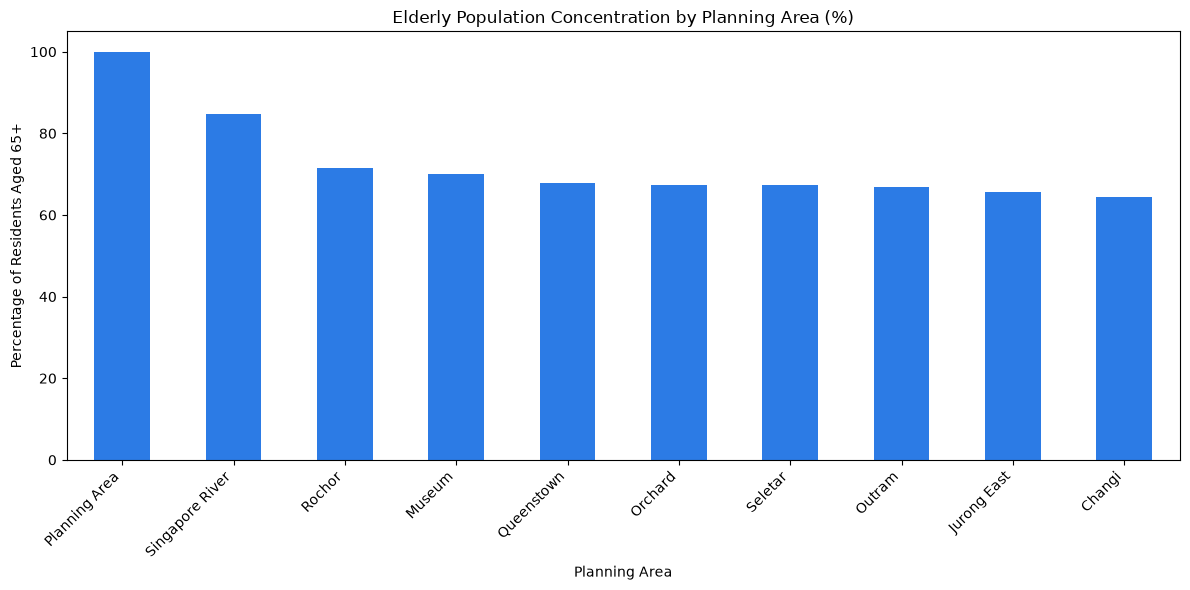

In [27]:
#DESCRIPTIVE STATISTICS: SPATIAL DISTRIBUTION 

# A. Top 10 Planning Areas by Elderly Concentration (Table for 3.2)
top_elderly_areas = df_subzone.groupby("planning_area").agg(
    elderly_pct=("elderly_pct", "mean"),
    total_elderly=("elderly_pop", "sum"),
    avg_dependency=("dependency_ratio", "mean")
).sort_values("elderly_pct", ascending=False).head(10).round(2)

print("Top 10 Planning Areas by Elderly Concentration:")
print(top_elderly_areas)

# B. Prepare Choropleth Data (Figure for 3.2)
# Note: For a true choropleth, merge this with a GeoJSON of Singapore planning areas
choro_data = df_subzone.groupby("planning_area")["elderly_pct"].mean().reset_index()
choro_data.columns = ["Planning Area", "Elderly %"]

# C. Bar Chart Alternative (If no GeoJSON available)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
top_elderly_areas["elderly_pct"].plot(kind="bar", color="#2c7be5")
plt.title("Elderly Population Concentration by Planning Area (%)")
plt.ylabel("Percentage of Residents Aged 65+")
plt.xlabel("Planning Area")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
#PRELIMINARY RELATIONSHIP CHECK

# A. Create Estate Type Proxy Variable
# Map planning areas to estate types based on HDB/URA classifications
estate_map = {
    "Bedok": "Mature Estate", "Tampines": "Mature Estate", "Toa Payoh": "Mature Estate",
    "Ang Mo Kio": "Mature Estate", "Hougang": "Mature Estate", "Jurong West": "Mature Estate",
    "Woodlands": "Non-Mature Estate", "Punggol": "Non-Mature Estate", 
    "Sengkang": "Non-Mature Estate", "Yishun": "Non-Mature Estate",
    "Downtown Core": "Central/Commercial", "Orchard": "Central/Commercial",
    "Marina Bay": "Central/Commercial", "Outram": "Central/Commercial"
}
df_subzone["estate_type"] = df_subzone["planning_area"].map(estate_map).fillna("Other")

# B. Cross-Tabulation: Elderly Proportion by Estate Type
cross_tab = df_subzone.groupby("estate_type")["elderly_pct"].agg(["mean", "std", "count"]).round(2)
cross_tab.columns = ["Mean Elderly %", "Std Dev", "Subzones"]
print("\nPreliminary Relationship: Elderly Concentration by Estate Type")
print(cross_tab)

# C. Narrative Generator for Section 3.3
mature_avg = cross_tab.loc["Mature Estate", "Mean Elderly %"]
non_mature_avg = cross_tab.loc["Non-Mature Estate", "Mean Elderly %"]
diff = mature_avg - non_mature_avg

narrative = (f"Mature estates show a mean elderly concentration of {mature_avg:.1f}%, "
             f"which is {diff:.1f} percentage points higher than non-mature estates "
             f"({non_mature_avg:.1f}%). This suggests spatial clustering of elderly populations "
             f"in older residential zones, potentially correlating with proximity to established "
             f"healthcare infrastructure in these areas.")
print(f"\nNarrative for Report:\n{narrative}")


Preliminary Relationship: Elderly Concentration by Estate Type
                    Mean Elderly %  Std Dev  Subzones
estate_type                                          
Central/Commercial           63.67    10.83        14
Mature Estate                61.21     3.19        50
Non-Mature Estate            57.69     2.93        26
Other                        62.71    10.53       153

Narrative for Report:
Mature estates show a mean elderly concentration of 61.2%, which is 3.5 percentage points higher than non-mature estates (57.7%). This suggests spatial clustering of elderly populations in older residential zones, potentially correlating with proximity to established healthcare infrastructure in these areas.
